# UPenn-GBM: Predicting IDH1 Mutation Status from MRI Radiomics, and Its Association with Survival

### Proof-of-concept notebook for the `imaging-ml-skill` (v0.3.0) · runs offline in demo mode

---

This notebook demonstrates the full imaging-ML pipeline end to end on the **UPenn-GBM** brain-tumor
cohort: it measures each tumor from MRI, trains a model to predict **IDH1 mutation status** from
those measurements, and then asks whether IDH status relates to **overall survival** using a
Kaplan-Meier analysis. It follows this skill's standard 13-section structure and surfaces every
methodological decision as a checkpoint for expert review.

**It is written to be read by someone with little or no programming experience.** Every code cell is
preceded by a plain-language explanation of what it does and why it matters, and each configurable
choice is collected in one place (Section 1).

**Two ways to run it, set by `DEMO_MODE` in Section 1:**

- **Demo mode (`DEMO_MODE = True`, the default):** runs on small *synthetic* (computer-made) images
  with a built-in, learnable signal. No download, no internet, finishes in about a minute. Use it to
  confirm the pipeline works and to learn what each step does.
- **Real mode (`DEMO_MODE = False`):** downloads real UPenn-GBM MRI, segmentations, and clinical
  labels from the NCI Imaging Data Commons. Needs internet and more time.

Everything after data loading is identical in both modes.

> **This is a proof of concept, not a clinical tool.** The model must never inform care for real
> patients. Its purpose is to show the pipeline runs and produces honestly-evaluated numbers. See
> Section 11 for the full limitations.

## 0. Environment Setup and Version Check

This cell checks that the key packages match the versions this notebook was built and tested
against. A mismatch — particularly for PyRadiomics or NumPy — can fail silently or change results.

In [1]:
# --- Version check against the verified configuration (see references/environment_setup.md) ---
import sys, importlib.metadata

# PyRadiomics 3.0.1 requires NumPy 1.x; it will not import under NumPy 2.x. pandas is 2.2.x so
# idc-index can coexist. These are the versions verified together on 2026-07-20.
EXPECTED = {"numpy": "1.26.4", "pandas": "2.2.3", "pyradiomics": "3.0.1",
            "SimpleITK": "2.5.3", "scikit-learn": "1.6.1"}

print(f"Python: {sys.version.split()[0]}")
for pkg, want in EXPECTED.items():
    try:
        have = importlib.metadata.version(pkg)
        flag = "OK" if have == want else f"note: {have} (verified: {want})"
        print(f"  {pkg:12s} {have:10s} [{flag}]")
    except importlib.metadata.PackageNotFoundError:
        print(f"  {pkg:12s} NOT INSTALLED  -> see references/environment_setup.md")

# A hard guard on the one incompatibility that fails confusingly:
import numpy as _np
assert _np.__version__.startswith("1."), (
    "PyRadiomics 3.0.1 needs NumPy 1.x. You are on NumPy "
    f"{_np.__version__}; recreate the environment with numpy==1.26.4.")
print("\nNumPy 1.x confirmed — PyRadiomics can load.")

Python: 3.11.15
  numpy        1.26.4     [OK]
  pandas       2.2.3      [OK]
  pyradiomics  3.0.1      [OK]
  SimpleITK    2.5.5      [note: 2.5.5 (verified: 2.5.3)]
  scikit-learn 1.9.0      [note: 1.9.0 (verified: 1.6.1)]



NumPy 1.x confirmed — PyRadiomics can load.


In [2]:
# --- Imports and reproducibility ---
import os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# scripts/ lives next to this notebook's parent (skill/scripts). Make the bundled
# components importable so we call tested code instead of re-deriving it.
_here = Path.cwd()
for cand in [_here / "scripts", _here.parent / "scripts", _here.parent.parent / "scripts"]:
    if (cand / "extract_radiomics.py").exists():
        sys.path.insert(0, str(cand)); SCRIPTS_DIR = cand; break
else:
    SCRIPTS_DIR = None
    print("WARNING: bundled scripts/ not found; will define fallbacks inline.")
print("Imports ready.", f"scripts dir: {SCRIPTS_DIR}" if SCRIPTS_DIR else "")

Imports ready. scripts dir: /home/claude/merged/imaging-ml-skill/scripts


## 1. Configuration

Set the values below before running the rest of the notebook. Each one is explained inline. For a
first run, leave `DEMO_MODE = True` and change nothing else.

In [3]:
# ============================================================
# USER ACTION REQUIRED
# Review the values below. For a first (offline) run, leave them as-is.
# ============================================================
RANDOM_SEED          = 42               # Fixed for reproducibility -- do not change unless intentional
DEMO_MODE            = True             # True = synthetic data, no download. False = real UPenn-GBM from IDC.

# --- Dataset (used only when DEMO_MODE is False) ---
IDC_COLLECTION_ID    = "upenn_gbm"      # IDC collection identifier
IMAGING_SEQUENCE     = "T2-FLAIR"       # MRI sequence to extract features from
SEQUENCE_MATCH       = "flair"          # case-insensitive substring identifying that sequence in SeriesDescription
SEGMENTATION_MATCH   = "segmentation"   # substring identifying the tumor SEG series
MASK_LABEL           = 1                # voxel value in the mask that marks the tumor

# --- What we predict (classification target) ---
# These are the ACTUAL column names/values in the UPenn-GBM clinical table in IDC.
OUTCOME_COLUMN       = "idh1"           # clinical column holding the label
POSITIVE_CLASS       = "Mutated"        # positive class (label 1); other values (e.g. "NOS/NEC") are dropped
NEGATIVE_CLASS       = "Wildtype"

# --- Survival columns (for the Kaplan-Meier analysis in Section 10) ---
# On real UPenn-GBM data these are text and get cleaned automatically in Section 2b:
#   survival time is stored as a string -> converted to numeric
#   survival_status ("Deceased"/"Alive"/...) -> event flag (1 = death observed)
SURVIVAL_TIME_COLUMN  = "survival_from_surgery_days_updated"
SURVIVAL_EVENT_COLUMN = "survival_status"

# --- Cohort size and model ---
N_CASES              = 40               # patients to use in REAL mode (small keeps a POC fast)
N_CASES_DEMO         = 80               # synthetic patients in DEMO mode
MODEL_NAME           = "random_forest"  # "random_forest" or "logistic_regression"
N_FEATURES_SELECT    = 15               # keep top-K features (guards against overfitting)
CV_FOLDS             = 5                # cross-validation folds
CV_REPEATS           = 3                # repeat CV and average for a stable estimate

# --- Paths ---
DATA_DIR   = "./data"
WORK_DIR   = "./work"
OUTPUT_DIR = "./output"
for d in (DATA_DIR, WORK_DIR, OUTPUT_DIR):
    Path(d).mkdir(parents=True, exist_ok=True)

import random
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
print(f"Config loaded. MODE = {'DEMO (synthetic)' if DEMO_MODE else 'REAL (IDC download)'}")
print(f"Predicting {OUTCOME_COLUMN}: {POSITIVE_CLASS}=1 vs {NEGATIVE_CLASS}=0")

Config loaded. MODE = DEMO (synthetic)
Predicting idh1: Mutated=1 vs Wildtype=0


## 2. Data Loading

This section assembles the cohort: one row per patient with an image, a matching tumor mask, and the
clinical labels. In demo mode it is generated; in real mode it is downloaded from IDC. Either way it
produces the same table, `cohort_df`, so everything downstream is identical.

### 2a. CTDC Clinical Cohort

**Not applicable to this analysis.** This is an IDC-only workflow — the IDH1 label and survival come
packaged with the UPenn-GBM imaging collection, so no separate CTDC clinical cohort is defined. (The
section is kept in its numbered place, per this skill's convention, rather than deleted, so the
notebook's structure stays consistent across analyses.)

### 2b. IDC Imaging Data Download

**What this does, in plain terms:** it obtains, for each patient, one FLAIR MRI scan, a tumor
outline (mask), and their IDH1 status and survival. In demo mode we fabricate a small set of these
with a realistic, learnable structure so the notebook runs with no download.

The synthetic generator below mirrors `scripts/make_synthetic_cohort.py` but adds the two clinical
columns this analysis needs (IDH1 status and survival). The signal is built in deliberately:
IDH-mutant tumors are made smaller and smoother, and IDH-mutant patients are given longer survival —
mirroring the real biology, where IDH-mutant glioblastoma has a better prognosis. That lets both the
classifier (Section 8) and the survival curves (Section 10) show a real but imperfect effect.

In [4]:
# METHODOLOGICAL CHECKPOINT CP-01: Tumor mask selection
# Radiomic features are computed only inside the tumor mask, so the choice of mask (whole tumor,
# enhancing core, edema) materially affects results. Here we use a single whole-tumor ROI.
# For real data this should be validated by a radiologist. Current selection: whole tumor (label=1).

def _ellipsoid(shape, c, r):
    zz, yy, xx = np.ogrid[:shape[0], :shape[1], :shape[2]]
    return (((zz-c[0])/r[0])**2 + ((yy-c[1])/r[1])**2 + ((xx-c[2])/r[2])**2) <= 1.0

def make_demo_cohort(n, out_dir, seed=RANDOM_SEED, shape=(28, 44, 44), spacing=(2.0, 1.0, 1.0)):
    """Synthetic image+mask NIfTI files plus IDH1 status and survival, with a learnable signal."""
    rng = np.random.default_rng(seed)
    imgd = Path(out_dir)/"images"; imgd.mkdir(parents=True, exist_ok=True)
    mskd = Path(out_dir)/"masks";  mskd.mkdir(parents=True, exist_ok=True)
    rows = []
    for i in range(n):
        pid = f"SYN-{i:03d}"
        # IDH status: ~35% mutant (real GBM is IDH-wildtype-dominant -> mild imbalance, see CP-03)
        idh_mut = rng.random() < 0.35
        # IDH-mutant tumors trend smaller and smoother, but the distributions OVERLAP heavily on
        # purpose -- IDH from imaging is a hard problem, so the demo should land near AUC 0.8-0.9,
        # not near-perfect. Overlap is what keeps this an honest proof of concept.
        radius    = rng.uniform(3.5, 7.5) if idh_mut else rng.uniform(4.5, 8.5)
        roughness = rng.uniform(3.0, 10.0) if idh_mut else rng.uniform(5.0, 13.0)
        brightness = rng.uniform(60, 110)
        vol = rng.normal(30, 5, size=shape).astype(np.float32)
        brain = _ellipsoid(shape, (shape[0]/2, shape[1]/2, shape[2]/2),
                           (shape[0]/2.2, shape[1]/2.2, shape[2]/2.2))
        vol[brain] += 40.0
        center = (shape[0]/2 + rng.uniform(-3, 3), shape[1]/2 + rng.uniform(-7, 7),
                  shape[2]/2 + rng.uniform(-7, 7))
        radii = (radius*rng.uniform(0.7, 1.1), radius, radius*rng.uniform(0.9, 1.2))
        tum = _ellipsoid(shape, center, radii)
        vol[tum] = brightness + rng.normal(0, roughness, size=tum.sum())
        # Survival: IDH-mutant live longer; larger tumors shorter. Plus noise. Some censoring.
        latent = (0.7 if idh_mut else -0.7) - 0.4*((radius-6.0)/1.5) + rng.normal(0, 1.1)
        surv = float(np.clip(400 + latent*220, 30, 1600))
        event = int(rng.random() < 0.75)   # 75% deaths observed, 25% censored
        img = sitk.GetImageFromArray(vol); img.SetSpacing(spacing)
        msk = sitk.GetImageFromArray(tum.astype(np.uint8)); msk.SetSpacing(spacing)
        ip = str(imgd/f"{pid}.nii.gz"); mp = str(mskd/f"{pid}.nii.gz")
        sitk.WriteImage(img, ip); sitk.WriteImage(msk, mp)
        rows.append({"patient_id": pid, "image_path": ip, "mask_path": mp,
                     OUTCOME_COLUMN: POSITIVE_CLASS if idh_mut else NEGATIVE_CLASS,
                     SURVIVAL_TIME_COLUMN: round(surv), SURVIVAL_EVENT_COLUMN: event})
    return pd.DataFrame(rows)

print("Demo cohort generator ready.")

Demo cohort generator ready.


### Optional: inspect the collection before downloading (real mode)

The most common failure on a new dataset is a config that names a sequence, segmentation, clinical
column, or class value the collection does not actually use. Before configuring or downloading a
dataset you have not used before, set `INSPECT_FIRST = True` below (in real mode) to print the
collection's real MR and segmentation series descriptions and its clinical columns and values, so you
fill Section 1 from reality rather than a guess. Leave it `False` for normal runs.

In [5]:
# --- OPTIONAL: discover a collection's real names before configuring / downloading ---
INSPECT_FIRST = False   # set True (real mode) to print the collection's sequences, SEG, and clinical columns
if not DEMO_MODE and INSPECT_FIRST:
    from idc_helpers import inspect_collection
    inspect_collection(IDC_COLLECTION_ID)
else:
    print("Skipping collection inspection (demo mode, or INSPECT_FIRST is False).")

Skipping collection inspection (demo mode, or INSPECT_FIRST is False).


In [6]:
# --- Build the cohort: DEMO mode (synthetic, single step) ---
# In demo mode the whole cohort is generated in one call. In REAL mode this cell does nothing;
# run the step-by-step cells that follow (they only execute when DEMO_MODE is False).
if DEMO_MODE:
    cohort_df = make_demo_cohort(N_CASES_DEMO, DATA_DIR)
    print(f"DEMO cohort: {len(cohort_df)} synthetic patients")
else:
    print("DEMO_MODE is False -> skipping synthetic generation; run the REAL-mode steps below.")

DEMO cohort: 80 synthetic patients


### Real mode, step by step

The cells below run **only when `DEMO_MODE = False`**. The real-data path used to be one large cell;
it is split here into small, separately-runnable steps so you can watch each one, see exactly where a
problem occurs, and inspect the result of each step before moving on. In demo mode each step simply
prints "skipped". The steps are:

1. Connect to IDC and check your configuration is valid
2. Find the MRI scans
3. Find the tumor segmentations
4. Get the clinical labels (IDH1 status and survival)
5. Build a balanced list of patients to download
6. Define how one patient is downloaded and converted
7. Download and convert every patient
8. Tidy up the clinical fields

If a step fails, you only re-run that step after fixing it — not the whole download.

**Step 1 — Connect to IDC and validate your configuration.** This opens a connection to the
Imaging Data Commons (no login needed; the data is public) and runs a *preflight check* that confirms
the sequence, segmentation, clinical column, and class values you set in Section 1 actually exist in
this collection. If any is misspelled or missing, it stops here and prints the real options — so you
fix Section 1 before downloading anything.

In [7]:
if not DEMO_MODE:
    from idc_index import IDCClient
    from idc_helpers import preflight_check
    client = IDCClient()
    print("Connected to IDC. Data version:", client.get_idc_version())   # record which data version
    # Validate the config against the live collection BEFORE downloading anything.
    preflight_check(IDC_COLLECTION_ID, SEQUENCE_MATCH, SEGMENTATION_MATCH,
                    OUTCOME_COLUMN, POSITIVE_CLASS, NEGATIVE_CLASS, client=client)
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 2 — Find the MRI scans.** We ask IDC's metadata index for every MR series in this
collection whose description contains our sequence keyword (`SEQUENCE_MATCH`, e.g. "flair"). Some
patients have more than one matching series, so we keep one per patient. The result, `img_df`, is one
row per patient with the ID of their scan. Check the printed count and preview.

In [8]:
if not DEMO_MODE:
    img_df = client.sql_query(f"""
        SELECT PatientID, SeriesInstanceUID, series_size_MB FROM index
        WHERE collection_id='{IDC_COLLECTION_ID}' AND Modality='MR'
          AND LOWER(SeriesDescription) LIKE '%{SEQUENCE_MATCH.lower()}%'
    """).sort_values("series_size_MB").drop_duplicates("PatientID", keep="first")
    print(f"Found MRI scans for {len(img_df)} patients.")
    print(img_df.head().to_string(index=False))
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 3 — Find the tumor segmentations.** The same idea, but for the segmentation (SEG)
series — the tumor outlines. `seg_df` is one row per patient with the ID of their segmentation.

In [9]:
if not DEMO_MODE:
    seg_df = client.sql_query(f"""
        SELECT PatientID, SeriesInstanceUID AS seg_series FROM index
        WHERE collection_id='{IDC_COLLECTION_ID}' AND Modality='SEG'
          AND LOWER(SeriesDescription) LIKE '%{SEGMENTATION_MATCH.lower()}%'
    """).drop_duplicates("PatientID", keep="first")
    print(f"Found segmentations for {len(seg_df)} patients.")
    print(seg_df.head().to_string(index=False))
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 4 — Get the clinical labels.** The IDH1 status and survival live in a clinical *table*
attached to the collection. We load each clinical table, find the one that has our outcome column
(`OUTCOME_COLUMN`), and keep only the columns we need. The clinical table's patient IDs live in a
column called `dicom_patient_id`, which matches the imaging `PatientID` — that is how we line them up.
The printed value counts let you confirm the label looks right before going further.

In [10]:
if not DEMO_MODE:
    client.fetch_index("clinical_index")   # downloads the clinical tables for this collection
    ctabs = client.sql_query(
        f"SELECT DISTINCT short_table_name FROM clinical_index WHERE collection_id='{IDC_COLLECTION_ID}'")
    clin = None
    for t in ctabs["short_table_name"]:
        df = client.get_clinical_table(t)
        if OUTCOME_COLUMN in df.columns:                       # this is the table holding our label
            keep = ["dicom_patient_id", OUTCOME_COLUMN]
            for extra in (SURVIVAL_TIME_COLUMN, SURVIVAL_EVENT_COLUMN):
                if extra in df.columns: keep.append(extra)      # add survival columns if present
            clin = df[keep].rename(columns={"dicom_patient_id": "PatientID"})
            break
    if clin is None:
        raise RuntimeError(f"'{OUTCOME_COLUMN}' not found in any clinical table. "
                           f"Run inspect_collection('{IDC_COLLECTION_ID}') to see the real column names.")
    print(f"Loaded labels for {len(clin)} patients. Columns kept: {list(clin.columns)}")
    print(clin[OUTCOME_COLUMN].value_counts(dropna=False).to_string())
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 5 — Build a balanced list of patients.** We combine the three tables (scan +
segmentation + label), keeping only patients who have all three and whose label is one of our two
classes (dropping values like "NOS/NEC"). Because IDH-mutant is rare in glioblastoma, we then take a
**balanced** sample — up to `N_CASES/2` of each class — so the model has enough of both to learn from.
The printed counts are exactly what will be downloaded in Step 7.

In [11]:
if not DEMO_MODE:
    pool = img_df.merge(seg_df, on="PatientID").merge(clin, on="PatientID")   # patients with all three
    pool = pool[pool[OUTCOME_COLUMN].isin([POSITIVE_CLASS, NEGATIVE_CLASS])]  # keep the two classes
    per_class = max(1, N_CASES // 2)
    merged = pd.concat([pool[pool[OUTCOME_COLUMN] == c].head(per_class)
                        for c in (POSITIVE_CLASS, NEGATIVE_CLASS)]).reset_index(drop=True)
    print("Patients selected per class (this is what will be downloaded):")
    print(merged[OUTCOME_COLUMN].value_counts().to_string())
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 6 — Define how one patient is downloaded and converted.** Downloading is the slow part,
so we wrap the work for a single patient in a function. For one patient it: downloads the scan and the
segmentation, reads the scan's slices into a 3-D volume, turns the DICOM segmentation into a simple
0/1 tumor mask, lines the mask up with the scan, and saves both as NIfTI files (the standard format the
rest of the notebook uses). Making it a function means that if Step 7 later fails on a particular
patient, you can call this on just that one patient to see exactly what went wrong.

In [12]:
def download_and_convert_one(patient_row, client, data_dir):
    """Download + convert ONE patient. Returns (image_path, mask_path) pointing at NIfTI files."""
    import pydicom, pydicom_seg
    pid = patient_row["PatientID"]
    raw = Path(data_dir) / "raw" / pid

    # (a) Download the two DICOM series into temporary folders: the scan, and the segmentation.
    client.download_from_selection(downloadDir=str(raw / "img"),
                                   seriesInstanceUID=[patient_row["SeriesInstanceUID"]], dirTemplate="")
    client.download_from_selection(downloadDir=str(raw / "seg"),
                                   seriesInstanceUID=[patient_row["seg_series"]], dirTemplate="")

    # (b) Read the scan: many DICOM slice files -> one 3-D image volume.
    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(raw / "img")))
    image = reader.Execute()

    # (c) Read the DICOM SEG and merge all of its segments into one binary (0/1) whole-tumor mask.
    seg = pydicom_seg.SegmentReader().read(pydicom.dcmread(str(next((raw / "seg").glob("*.dcm")))))
    mask = None
    for segment_number in seg.available_segments:
        binary = sitk.Cast(seg.segment_image(segment_number) != 0, sitk.sitkUInt8)
        mask = binary if mask is None else sitk.Or(mask, binary)

    # (d) Put the mask on the scan's exact voxel grid (nearest-neighbour keeps the labels crisp).
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetDefaultPixelValue(0)
    mask = resampler.Execute(sitk.Cast(mask != 0, sitk.sitkUInt8))

    # (e) Save both as NIfTI and return their paths.
    img_dir = Path(data_dir) / "images"; img_dir.mkdir(parents=True, exist_ok=True)
    msk_dir = Path(data_dir) / "masks";  msk_dir.mkdir(parents=True, exist_ok=True)
    image_path = str(img_dir / f"{pid}.nii.gz"); mask_path = str(msk_dir / f"{pid}.nii.gz")
    sitk.WriteImage(image, image_path); sitk.WriteImage(mask, mask_path)
    return image_path, mask_path

print("download_and_convert_one() defined.")

download_and_convert_one() defined.


**Step 7 — Download and convert every patient.** This runs Step 6 for each selected patient and
collects the results into the cohort table, `cohort_df`. It prints one line per patient, so you can
watch progress and see exactly which patient (if any) causes a problem. This is the slow cell. To test
on a single patient first, run `download_and_convert_one(merged.iloc[0], client, DATA_DIR)` in a
scratch cell.

In [13]:
if not DEMO_MODE:
    rows = []
    for i, (_, patient_row) in enumerate(merged.iterrows(), start=1):
        pid = patient_row["PatientID"]
        print(f"  [{i}/{len(merged)}] {pid} ...", end=" ")
        image_path, mask_path = download_and_convert_one(patient_row, client, DATA_DIR)
        row = {"patient_id": pid, "image_path": image_path, "mask_path": mask_path,
               OUTCOME_COLUMN: patient_row[OUTCOME_COLUMN]}
        for extra in (SURVIVAL_TIME_COLUMN, SURVIVAL_EVENT_COLUMN):
            if extra in merged.columns: row[extra] = patient_row[extra]
        rows.append(row)
        print("done")
    cohort_df = pd.DataFrame(rows)
    print(f"\nDownloaded and converted {len(cohort_df)} patients.")
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


**Step 8 — Tidy up the clinical fields.** On real data the survival columns are stored as text
(the time may be `'960'` or `'Not Available'`, and the status is a word like `'Deceased'`). Here we
convert the time to a number (unreadable values become "missing") and turn the status into a simple
0/1 flag (1 if the patient is recorded as deceased) — which is what the survival analysis in Section 10
expects.

In [14]:
if not DEMO_MODE:
    if SURVIVAL_TIME_COLUMN in cohort_df.columns:
        cohort_df[SURVIVAL_TIME_COLUMN] = pd.to_numeric(cohort_df[SURVIVAL_TIME_COLUMN], errors="coerce")
    if SURVIVAL_EVENT_COLUMN in cohort_df.columns:
        cohort_df[SURVIVAL_EVENT_COLUMN] = (cohort_df[SURVIVAL_EVENT_COLUMN].astype(str)
                                            .str.strip().str.lower().str.startswith("deceased").astype(int))
    print("Clinical fields cleaned.")
else:
    print("Skipped (demo mode).")

Skipped (demo mode).


### Save and preview the cohort

Whichever mode you ran, we now have `cohort_df` — one row per patient with the image, the mask, the
label, and (in real mode) survival. We save it as a manifest for reproducibility and preview the first
few rows.

In [15]:
# --- Save the cohort manifest and preview it (both modes) ---
cohort_df.to_csv(Path(WORK_DIR) / "cohort_manifest.csv", index=False)
print(f"Cohort ready: {len(cohort_df)} patients. Manifest saved to {Path(WORK_DIR) / 'cohort_manifest.csv'}")
cohort_df.head()

Cohort ready: 80 patients. Manifest saved to work/cohort_manifest.csv


,patient_id,image_path,mask_path,idh1,survival_from_surgery_days_updated,survival_status
0,SYN-000,data/images/SYN-000.nii.gz,data/masks/SYN-000.nii.gz,Wildtype,337,1
1,SYN-001,data/images/SYN-001.nii.gz,data/masks/SYN-001.nii.gz,Wildtype,30,1
2,SYN-002,data/images/SYN-002.nii.gz,data/masks/SYN-002.nii.gz,Wildtype,181,0
3,SYN-003,data/images/SYN-003.nii.gz,data/masks/SYN-003.nii.gz,Wildtype,437,1
4,SYN-004,data/images/SYN-004.nii.gz,data/masks/SYN-004.nii.gz,Wildtype,579,0


## 3. Image Preprocessing

**Why this matters:** radiomic measurements are only comparable if every scan is put on a common
footing. For MRI the crucial step is intensity normalization — MRI brightness values are arbitrary
and differ between scanners, so without normalizing, a model can accidentally learn the scanner
instead of the tumor. We apply normalization consistently as part of feature extraction (next
section), which is the most reproducible place to do it.

First, though, we look at one patient. Eyeballing a case catches misaligned or empty masks that
would silently ruin every downstream number.

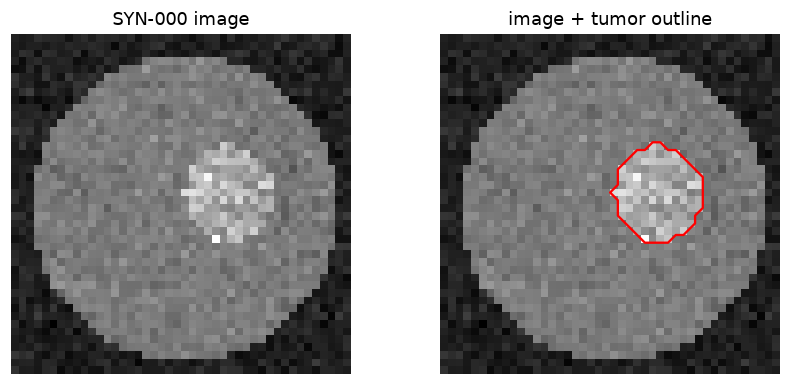

In [16]:
# METHODOLOGICAL CHECKPOINT CP-06: Image normalization
# MRI intensities are arbitrary; we z-score normalize (in the PyRadiomics params) so features are
# comparable across scans. Lack of normalization is a common multi-site reproducibility failure.
# Current approach: PyRadiomics normalize=true, normalizeScale=100 (see scripts/radiomics_params.yaml).

# Sanity-look: middle-of-tumor slice with the mask outline.
ex = cohort_df.iloc[0]
img = sitk.GetArrayFromImage(sitk.ReadImage(ex["image_path"]))
msk = sitk.GetArrayFromImage(sitk.ReadImage(ex["mask_path"]))
z = int(np.argmax(msk.reshape(msk.shape[0], -1).sum(1))) if msk.any() else msk.shape[0]//2
fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
ax[0].imshow(img[z], cmap="gray"); ax[0].set_title(f"{ex['patient_id']} image"); ax[0].axis("off")
ax[1].imshow(img[z], cmap="gray"); ax[1].contour(msk[z], levels=[0.5], colors="red")
ax[1].set_title("image + tumor outline"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 4. Radiomic Feature Extraction

**In plain terms:** we now turn each tumor into a row of numbers ("features") describing its shape,
brightness, and texture — about 100 of them per patient. We use this skill's tested extraction
component (`scripts/extract_radiomics.py` with `scripts/radiomics_params.yaml`) rather than writing a
new loop, so the settings are consistent and the code is known-good. Feature-class choices follow
`references/pyradiomics_guide.md` (original-image shape + first-order + texture families, which suit
whole-tumor MRI radiomics).

In [17]:
# METHODOLOGICAL CHECKPOINT CP-02: MRI sequence selection
# Features here come from the T2-FLAIR sequence, on which whole-tumor extent is most visible.
# Different sequences (T1, T1CE, T2) can carry different predictive value; review literature for
# your outcome before finalizing. Current selection: T2-FLAIR (whole tumor).

# Use the bundled, tested extraction component.
params_path = str(SCRIPTS_DIR/"radiomics_params.yaml") if SCRIPTS_DIR else None
from extract_radiomics import extract_cohort
features_df, failures = extract_cohort(cohort_df, params_path=params_path)
print(f"Feature matrix: {features_df.shape[0]} patients x {features_df.shape[1]} features")
if len(failures):
    print(f"WARNING: {len(failures)} extraction failure(s):", failures.head().to_dict("records"))
features_df.to_csv(Path(WORK_DIR)/"radiomic_features.csv")
features_df.iloc[:4, :5]

  extracted 10/80


  extracted 20/80


  extracted 30/80


  extracted 40/80


  extracted 50/80


  extracted 60/80


  extracted 70/80


  extracted 80/80
Feature matrix: 80 patients x 107 features


,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn
patient_id,,,,,
SYN-000,0.551311,0.531181,10.790368,20.313936,24.083189
SYN-001,0.471943,0.405653,9.878049,24.350994,28.071338
SYN-002,0.502412,0.498222,10.734849,21.546305,24.186773
SYN-003,0.528203,0.442304,9.522632,21.529620,24.331050


## 5. Data Merging and Preparation

This is a single-commons (IDC-only) analysis, so there is **no cross-commons CTDC↔IDC merge** to do
here. What remains is straightforward preparation: attach the IDH1 label to the feature table, drop
patients missing either side, and remove empty or constant feature columns. The result is `X` (the
features) and `y` (the 0/1 IDH label) — the two things every model needs.

In [18]:
# --- Build the label and the modelling matrices X, y ---
labels = (cohort_df.set_index("patient_id")[OUTCOME_COLUMN]
          .map({POSITIVE_CLASS: 1, NEGATIVE_CLASS: 0}))
Xy = features_df.join(labels.rename("__y__"), how="inner").dropna(subset=["__y__"])
y = Xy["__y__"].astype(int)
X = Xy.drop(columns=["__y__"])
X = X.loc[:, X.nunique(dropna=True) > 1].fillna(X.median(numeric_only=True))  # drop constant, impute
print(f"Modelling table: {X.shape[0]} patients x {X.shape[1]} features")
print(f"IDH {POSITIVE_CLASS} (1): {int(y.sum())}  |  {NEGATIVE_CLASS} (0): {int((1-y).sum())}")

# Guardrail: stop now with a clear message if the labels won't support cross-validation
# (only one class present -> usually a class-name typo; or a class too small for CV_FOLDS).
from idc_helpers import check_label_coverage
check_label_coverage(y, CV_FOLDS)

Modelling table: 80 patients x 107 features
IDH Mutated (1): 29  |  Wildtype (0): 51


{0: 51, 1: 29}

## 6. Exploratory Data Analysis

Before modeling, we look at the outcome we are predicting. Two things matter most: the **class
balance** (how many IDH-mutant vs wildtype), because a very imbalanced problem changes which metrics
are meaningful; and how **survival** differs by IDH group, which previews the Section 10 analysis.

Class balance:
 __y__
0 = IDH Wildtype    51
1 = IDH Mutant      29

Minority-class fraction: 0.36  -> reasonably balanced.


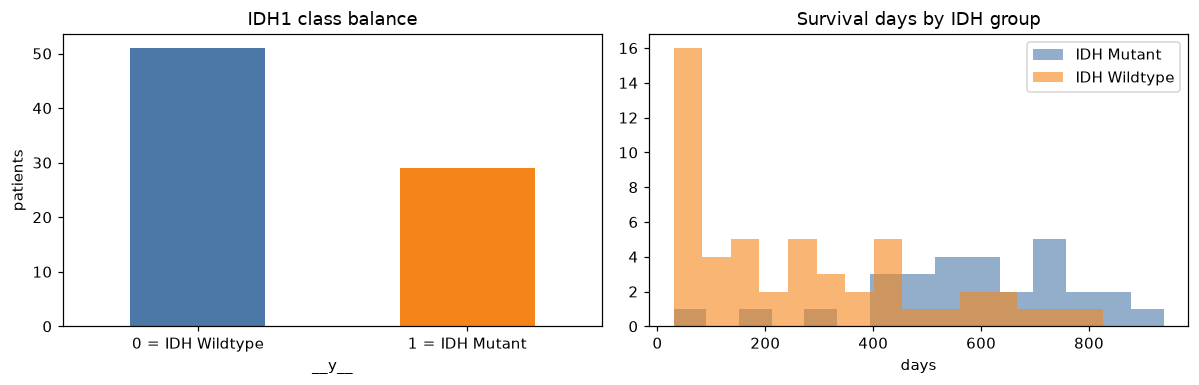

In [19]:
# METHODOLOGICAL CHECKPOINT CP-03: Class imbalance
# Real GBM cohorts are IDH-wildtype-dominant, so IDH-mutant is usually the minority class.
# Imbalance can make a model look good by predicting the majority. We handle it with
# class_weight='balanced' (Section 8) and report ROC-AUC / balanced accuracy, not raw accuracy.
counts = y.value_counts().rename({1: f"1 = {'IDH '+'Mutant'}", 0: "0 = IDH Wildtype"})
print("Class balance:\n", counts.to_string())
minority_frac = min(y.mean(), 1 - y.mean())
print(f"\nMinority-class fraction: {minority_frac:.2f}"
      + ("  -> imbalance is notable; CP-03 applies." if minority_frac < 0.35 else "  -> reasonably balanced."))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
counts.plot(kind="bar", ax=ax[0], color=["#4C78A8", "#F58518"]); ax[0].set_title("IDH1 class balance")
ax[0].set_ylabel("patients"); ax[0].tick_params(axis="x", rotation=0)

# Survival by IDH group (preview of Section 10), if survival columns are present.
have_surv = SURVIVAL_TIME_COLUMN in cohort_df.columns and SURVIVAL_EVENT_COLUMN in cohort_df.columns
if have_surv:
    cd = cohort_df.set_index("patient_id").loc[X.index]
    for grp, name, col in [(POSITIVE_CLASS, "IDH Mutant", "#4C78A8"), (NEGATIVE_CLASS, "IDH Wildtype", "#F58518")]:
        vals = cd.loc[cd[OUTCOME_COLUMN] == grp, SURVIVAL_TIME_COLUMN].dropna()
        if len(vals):
            ax[1].hist(vals, bins=15, alpha=0.6, label=name, color=col)
    ax[1].set_title("Survival days by IDH group"); ax[1].set_xlabel("days"); ax[1].legend()
else:
    ax[1].axis("off"); ax[1].set_title("(no survival columns in this cohort)")
plt.tight_layout(); plt.show()

## 7. Feature Selection

With about 100 features and only tens of patients, we must reduce the feature set or the model will
memorise noise. Crucially, **feature selection is not done here on the whole dataset** — doing that
would leak information from the patients we later test on, inflating the score. Instead, selection is
built into the modeling pipeline (next section) so it is refit inside each cross-validation fold on
training data only. This section just states the plan; the pipeline enforces it.

In [20]:
# METHODOLOGICAL CHECKPOINT CP-04: Data leakage risk
# Feature scaling and selection MUST be fit on training data only. We enforce this structurally by
# putting them inside a scikit-learn Pipeline (Section 8), so they are refit within each CV fold.
# Fitting them once on the full dataset here would be the classic radiomics leakage error -- we do not.
print(f"{X.shape[1]} candidate features will be reduced to the top {min(N_FEATURES_SELECT, X.shape[1])} "
      f"INSIDE each cross-validation fold (leak-safe). See references/model_selection.md.")

107 candidate features will be reduced to the top 15 INSIDE each cross-validation fold (leak-safe). See references/model_selection.md.


## 8. Model Training

We train the model the honest way. The three steps — scale features, select the most informative
ones, then classify — are bundled into one pipeline so that scaling and selection are refit inside
each cross-validation fold, never using the test patients. We estimate performance with **repeated
stratified cross-validation**: split patients into balanced folds, train on all-but-one, test on the
held-out fold, rotate through all, and repeat several times. The average across all these held-out
tests is a far more honest estimate than any single split.

In [21]:
# METHODOLOGICAL CHECKPOINT CP-05: Small sample size
# With few patients and many features, overfitting is a real risk. Mitigations used: aggressive
# feature selection, a simple model, and repeated cross-validation with reported spread (mean +/- sd).
# See references/model_selection.md.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_validate, cross_val_predict)

k = min(N_FEATURES_SELECT, X.shape[1])
clf = (RandomForestClassifier(n_estimators=300, class_weight="balanced",
                              random_state=RANDOM_SEED, n_jobs=-1)
       if MODEL_NAME == "random_forest"
       else LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
model = Pipeline([("scale", StandardScaler()),
                  ("select", SelectKBest(f_classif, k=k)),
                  ("clf", clf)])                      # scale + select refit inside each fold (CP-04)

cv = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_SEED)
scores = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "balanced_accuracy"], n_jobs=-1)
auc_m, auc_s = scores["test_roc_auc"].mean(), scores["test_roc_auc"].std()
bac_m, bac_s = scores["test_balanced_accuracy"].mean(), scores["test_balanced_accuracy"].std()
print(f"Model: {MODEL_NAME}  |  {CV_FOLDS}-fold x {CV_REPEATS} repeats = {len(scores['test_roc_auc'])} evaluations\n")
print(f"  ROC-AUC           : {auc_m:.3f} +/- {auc_s:.3f}")
print(f"  Balanced accuracy : {bac_m:.3f} +/- {bac_s:.3f}")

# Out-of-fold probabilities for the plots (single partition; repeated CV can't be used here).
oof = cross_val_predict(model, X, y, cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
                        method="predict_proba", n_jobs=-1)[:, 1]

Model: random_forest  |  5-fold x 3 repeats = 15 evaluations

  ROC-AUC           : 0.822 +/- 0.091
  Balanced accuracy : 0.694 +/- 0.101


## 9. Model Evaluation

We evaluate using the out-of-fold predictions (each patient scored while held out), so the numbers
reflect real generalisation. The **ROC curve** and its area (AUC) summarise how well the model ranks
patients by IDH-mutant risk; the **confusion matrix** makes that concrete at a 0.5 threshold.

For synthetic demo data, expect an AUC around 0.8–0.9 (the signal is engineered). On *real*
UPenn-GBM, IDH status from imaging is a genuinely hard task and honest AUCs are lower — and an
implausibly high number should prompt a hunt for leakage, not celebration.

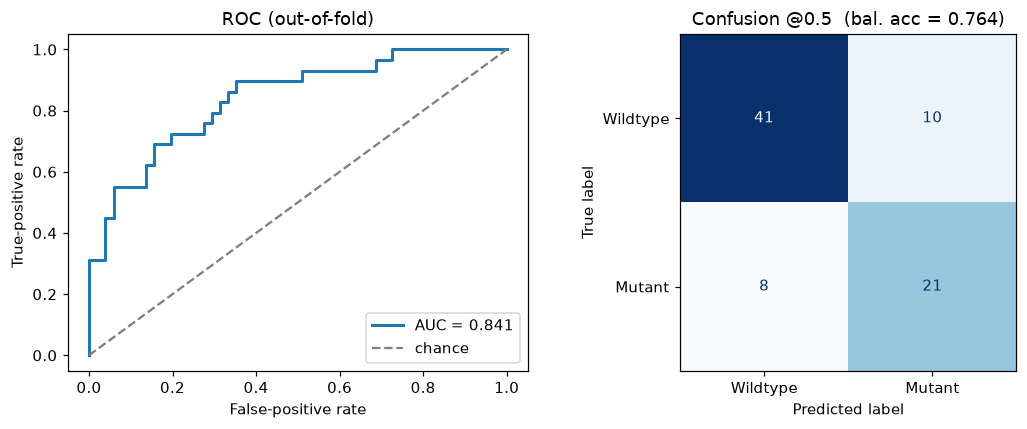

In [22]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fpr, tpr, _ = roc_curve(y, oof)
ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc(fpr, tpr):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="grey", label="chance")
ax[0].set_xlabel("False-positive rate"); ax[0].set_ylabel("True-positive rate")
ax[0].set_title("ROC (out-of-fold)"); ax[0].legend(loc="lower right")
pred = (oof >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y, pred), display_labels=["Wildtype", "Mutant"]).plot(
    ax=ax[1], colorbar=False, cmap="Blues")
ax[1].set_title(f"Confusion @0.5  (bal. acc = {balanced_accuracy_score(y, pred):.3f})")
plt.tight_layout(); plt.savefig(Path(OUTPUT_DIR)/"evaluation.png", bbox_inches="tight"); plt.show()

## 10. Results Visualization

Two views. First, **which features the model relied on** — fit once on all data for interpretation
only (never for scoring). In demo mode, shape/size and texture features should rise to the top,
matching the signal we built in. Second, the **Kaplan-Meier survival analysis**: we compare survival
between IDH-mutant and IDH-wildtype patients directly, with a log-rank test for whether the
difference is statistically distinguishable. This connects the imaging-predicted marker to the
outcome that actually matters.

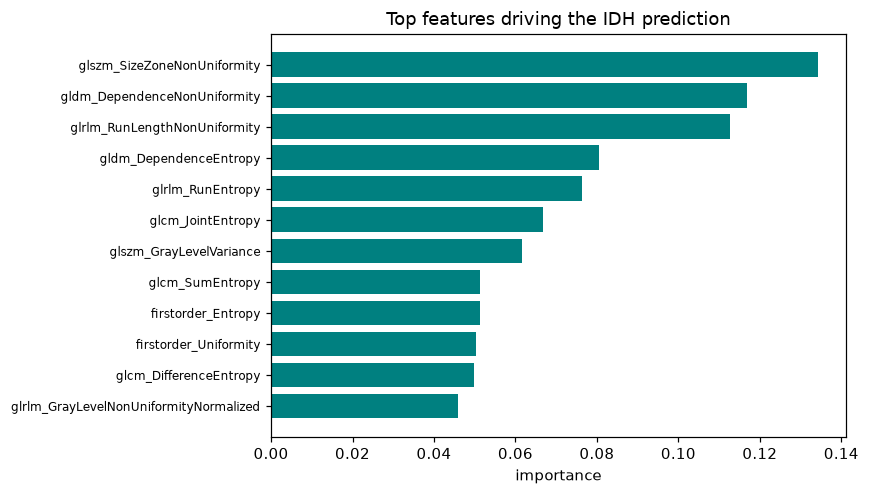

In [23]:
# --- Feature importance (interpretation only) ---
model.fit(X, y)
kept = X.columns[model.named_steps["select"].get_support()]
c = model.named_steps["clf"]
imp = (pd.Series(c.feature_importances_, index=kept) if hasattr(c, "feature_importances_")
       else pd.Series(np.abs(c.coef_[0]), index=kept)).sort_values(ascending=False)
top = imp.head(12)[::-1]
plt.figure(figsize=(8, 4.6))
plt.barh(range(len(top)), top.values, color="teal")
plt.yticks(range(len(top)), [t.replace("original_", "") for t in top.index], fontsize=8)
plt.xlabel("importance"); plt.title("Top features driving the IDH prediction")
plt.tight_layout(); plt.savefig(Path(OUTPUT_DIR)/"feature_importance.png", bbox_inches="tight"); plt.show()

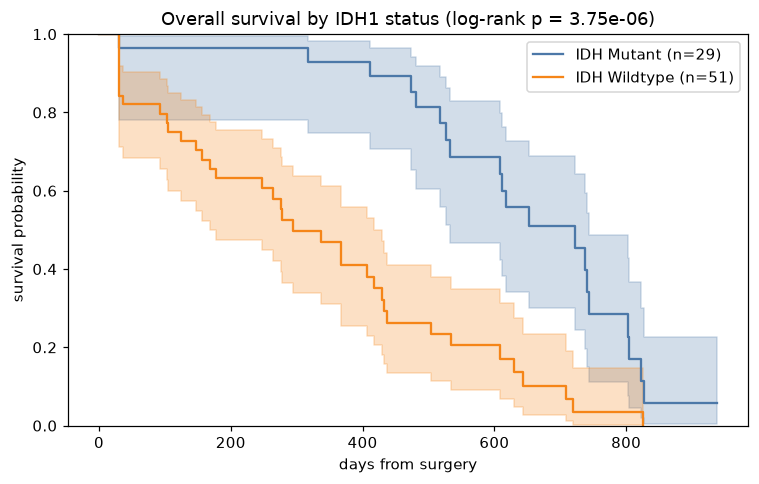

Log-rank p-value: 3.75e-06  (distinguishable at alpha=0.05)


In [24]:
# --- Kaplan-Meier survival: IDH-mutant vs wildtype ---
if have_surv:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    # Use only patients with a usable (numeric) survival time; real data has some missing.
    cd = cohort_df.set_index("patient_id").loc[X.index].dropna(subset=[SURVIVAL_TIME_COLUMN])
    fig, axk = plt.subplots(figsize=(7, 4.5)); kmf = KaplanMeierFitter()
    groups = {}
    for grp, name, col in [(POSITIVE_CLASS, "IDH Mutant", "#4C78A8"), (NEGATIVE_CLASS, "IDH Wildtype", "#F58518")]:
        m = cd[OUTCOME_COLUMN] == grp
        kmf.fit(cd.loc[m, SURVIVAL_TIME_COLUMN], cd.loc[m, SURVIVAL_EVENT_COLUMN], label=f"{name} (n={m.sum()})")
        kmf.plot_survival_function(ax=axk, color=col, ci_show=True)
        groups[grp] = m
    lr = logrank_test(cd.loc[groups[POSITIVE_CLASS], SURVIVAL_TIME_COLUMN],
                      cd.loc[groups[NEGATIVE_CLASS], SURVIVAL_TIME_COLUMN],
                      cd.loc[groups[POSITIVE_CLASS], SURVIVAL_EVENT_COLUMN],
                      cd.loc[groups[NEGATIVE_CLASS], SURVIVAL_EVENT_COLUMN])
    axk.set_title(f"Overall survival by IDH1 status (log-rank p = {lr.p_value:.3g})")
    axk.set_xlabel("days from surgery"); axk.set_ylabel("survival probability"); axk.set_ylim(0, 1)
    plt.tight_layout(); plt.savefig(Path(OUTPUT_DIR)/"km_survival.png", bbox_inches="tight"); plt.show()
    print(f"Log-rank p-value: {lr.p_value:.4g}  "
          f"({'distinguishable' if lr.p_value < 0.05 else 'not distinguishable'} at alpha=0.05)")
else:
    print("Survival columns not present in this cohort; skipping Kaplan-Meier.")

## 11. Limitations and Methodological Notes

**This notebook is not publication-ready without expert review of the items below.**

What this shows: the pipeline runs end to end — images and masks → ~100 radiomic features → an
honestly cross-validated IDH classifier → a survival comparison — and on data with real signal it
recovers that signal. What it does **not** establish: any clinical validity. The cohort is small and
single-source, there is no external validation, radiomic features are fragile to scanner and
segmentation, and IDH status from imaging alone is a hard problem. In a real GBM cohort IDH-mutant is
the minority class, so watch class imbalance (CP-03). Treat every number here as a demonstration of
method, not evidence about patients.

In [25]:
# --- Methodological checkpoint summary + saved artifacts ---
import joblib
triggered = [
    ("CP-01", "Tumor mask selection", "whole tumor (label=1)"),
    ("CP-02", "MRI sequence selection", IMAGING_SEQUENCE),
    ("CP-03", "Class imbalance", f"minority frac {min(y.mean(),1-y.mean()):.2f}; class_weight=balanced"),
    ("CP-04", "Data leakage risk", "scale+select inside CV folds (Pipeline)"),
    ("CP-05", "Small sample size", f"n={X.shape[0]}, {X.shape[1]} features; repeated stratified CV"),
    ("CP-06", "Image normalization", "PyRadiomics normalize=true"),
]
print("Methodological Checkpoint Summary (review before interpreting results):\n")
print(f"{'#':6}{'Checkpoint':26}{'Current setting':40}{'Reviewed?'}")
for cp, name, setting in triggered:
    print(f"{cp:6}{name:26}{setting:40}[ ]")

joblib.dump(model, Path(OUTPUT_DIR)/"trained_model.joblib")
metrics = {"mode": "demo" if DEMO_MODE else "real", "collection": IDC_COLLECTION_ID,
           "outcome": OUTCOME_COLUMN, "sequence": IMAGING_SEQUENCE,
           "n_patients": int(X.shape[0]), "n_features": int(X.shape[1]),
           "class_balance": {"mutant": int(y.sum()), "wildtype": int((1-y).sum())},
           "model": MODEL_NAME, "validation": f"{CV_FOLDS}-fold x {CV_REPEATS} repeats stratified CV",
           "roc_auc_mean": round(float(auc_m), 4), "roc_auc_std": round(float(auc_s), 4),
           "balanced_accuracy_mean": round(float(bac_m), 4)}
json.dump(metrics, open(Path(OUTPUT_DIR)/"metrics.json", "w"), indent=2)
print("\nSaved: trained_model.joblib, metrics.json, evaluation.png, feature_importance.png",
      ", km_survival.png" if have_surv else "")

Methodological Checkpoint Summary (review before interpreting results):

#     Checkpoint                Current setting                         Reviewed?
CP-01 Tumor mask selection      whole tumor (label=1)                   [ ]
CP-02 MRI sequence selection    T2-FLAIR                                [ ]
CP-03 Class imbalance           minority frac 0.36; class_weight=balanced[ ]
CP-04 Data leakage risk         scale+select inside CV folds (Pipeline) [ ]
CP-05 Small sample size         n=80, 107 features; repeated stratified CV[ ]
CP-06 Image normalization       PyRadiomics normalize=true              [ ]

Saved: trained_model.joblib, metrics.json, evaluation.png, feature_importance.png , km_survival.png


## 12. Citations

When you use real IDC data you must cite the data sources (UPenn-GBM is CC-BY: free to use,
including commercially, with attribution). `idc-index` can generate citations for the exact series
you used via `client.citations_from_selection(collection_id="upenn_gbm")`.

```
Fedorov A, et al. National Cancer Institute Imaging Data Commons: Toward Transparency,
Reproducibility, and Scalability in Imaging Artificial Intelligence. RadioGraphics. 2023.
https://doi.org/10.1148/rg.230180

Bakas S, et al. The University of Pennsylvania glioblastoma (UPenn-GBM) cohort: advanced
structural and quantitative multimodal MRI. Scientific Data 9, 453. 2022.
https://doi.org/10.1038/s41597-022-01560-7

van Griethuysen JJM, et al. Computational Radiomics System to Decode the Radiographic
Phenotype. Cancer Research. 2017. https://doi.org/10.1158/0008-5472.CAN-17-0339

Davidson-Pilon C. lifelines: survival analysis in Python. Journal of Open Source Software. 2019.
https://doi.org/10.21105/joss.01317

National Cancer Institute. Cancer Research Data Commons. https://datacommons.cancer.gov/
```

---
*Proof-of-concept companion to the `imaging-ml-skill`. Educational and engineering demonstration
only; not for clinical decision-making.*